# Germán Cousillas Martínez

$\huge{\text{Parte 1}}$

# Apartado 1

In [1]:
# Definimos constantes del problema
V0=0.5
r0=1
C2=0.02
C3=0.05
C4=0.01

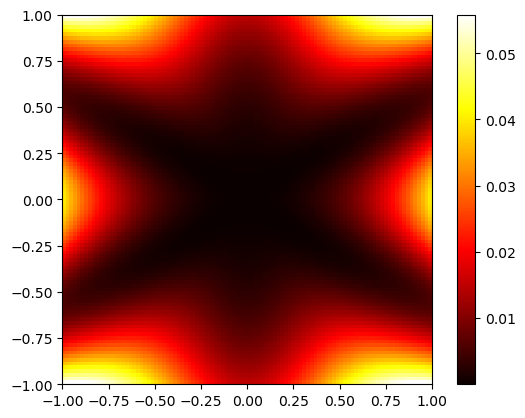

In [2]:
# Creamos trampa de potencial
import numpy as np
import matplotlib.pyplot as plt

N=100
x = np.linspace(-1,1,N)
X, Y = np.meshgrid(x, x)
R = np.sqrt(X**2+Y**2)
THETA = np.arctan2(Y, X)


V = V0 * ( C2*R**2*np.cos(2*THETA)**2 + C3*R**3*np.cos(3*THETA)**2 + C4*R**4*np.cos(4*THETA)**2)

plt.imshow(V, extent=[-1,1,-1,1], cmap="hot")
plt.colorbar()
plt.show()

In [3]:
# Ahora buscamos mínimo (parece que está en el origen de coordenadas)
from scipy.interpolate import RectBivariateSpline

def razon_aurea(f, x1, x4, tol):
    z = (1+np.sqrt(5))/2
    
    x2 = x4 - (x4-x1)/z
    x3 = x1 + (x4-x1)/z
    
    err = 1.0
    
    while err > tol:
        if f(x2) < f(x3): # Vamos en el buen camino si vamos hacia la izq.
            x4 = x3
            x3 = x2
            x2 = x4 - (x4-x1)/z
        else:
            x1 = x2
            x2 = x3
            x3 = x1 + (x4-x1)/z
        err = np.abs(x4-x1)
    return (x1+x4)/2

def grad(f, X0): # Evalúa el gradiente en un punto
    x0, y0 = X0
    h = 10**(-3)
    
    der_x = (f(x0+h/2, y0)-f(x0-h/2, y0))/h
    der_y = (f(x0, y0+h/2)-f(x0, y0-h/2))/h
    
    return np.array([der_x[0][0], der_y[0][0]])

def max_pendiente(F, X0, tol):
    err = 2*tol
    while err > tol:
        v = grad(F, X0)
        D = v/np.linalg.norm(v)
        
        g = lambda alpha: F(X0[0]+alpha*D[0], X0[1]+alpha*D[1])
        alpha = razon_aurea(g, -0.5,0.5,1e-3)
        
        X1 = X0+alpha*D
        err = np.max(np.abs(X1-X0))
        X0=X1
    return X1

f_V = RectBivariateSpline(x, x, V.T)

X_min = max_pendiente(f_V, [0.2,0.2], 1e-5)

V_min = f_V(X_min[0], X_min[1])

print(f"Punto del mínimo: (x,y)=({X_min[0]}, {X_min[1]})")
print(f"Valor mínimo del potencial: V_min = {V_min[0][0]}eV")

Punto del mínimo: (x,y)=(-0.00017708088448457258, -0.00011673572704996797)
Valor mínimo del potencial: V_min = -1.8268107997956423e-06eV


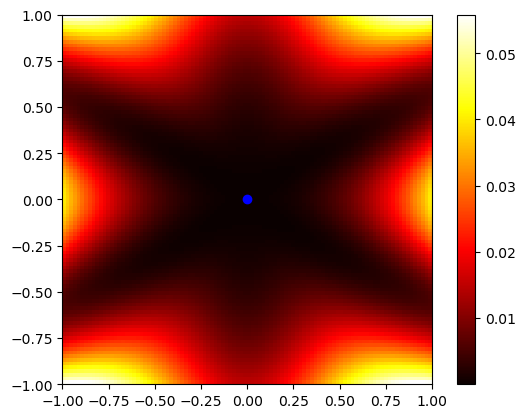

In [4]:
plt.imshow(f_V(x, x).T, extent=[-1,1,-1,1], cmap="hot")
plt.colorbar()

plt.plot(X_min[0], X_min[1], "bo")
plt.show()

## Apartado 2

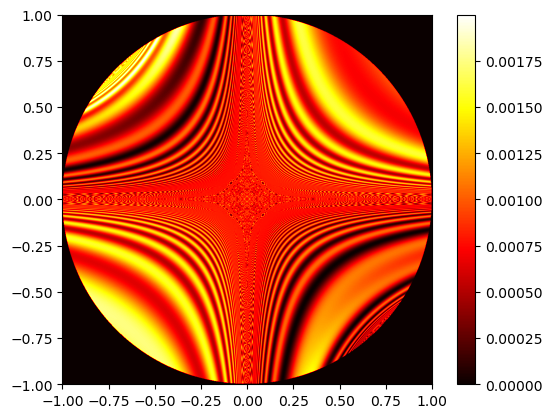

In [5]:
# Representamos el integrando
import numpy as np
import matplotlib.pyplot as plt

def F(x, y):
        return 1e-3*( np.cos(1/(2*x*y-1))**2 + np.sin(1/x/y+y)**2 )

F = np.vectorize(F)

x = np.linspace(-1,1,1000)

X, Y = np.meshgrid(x,x)

Z=F(X,Y)
Z[X**2+Y**2>1]=0

plt.imshow(Z, extent=[-1,1,-1,1], cmap="hot")
plt.colorbar()
plt.show()

In [6]:
# Hacemos la integral

def F(r):
    x, y = r
    if x**2+y**2 > 1:
        return 0
    return 1e-3*( np.cos(1/(2*x*y-1))**2 + np.sin(1/x/y+y)**2 )


N=1000000
S=0

for i in range(N):
    r = 2*np.random.rand(2)-1
    S+=F(r)
    
I = 4*S/N
print(I)

0.002710239632214451


In [7]:
import numpy as np
from gaussxw import gaussxw

# Calculo los pesos correspondientes a distintas variables 1 sola vez
N=100
t, w = gaussxw(N)

a=0
b=1
x = 1/2*((b-a)*t+(b-a))
wx = 1/2*(b-a)*w

a=0
b=2*np.pi
y = 1/2*((b-a)*t+(b-a))
wy = 1/2*(b-a)*w

def F(r, theta):
    return r*1e-3*(np.cos(1/(r**2*np.sin(theta/2)-1))**2+np.sin(2/r**2/np.sin(theta/2)+r*np.sin(theta))**2)

# Procedimiento 1
X, Y = np.meshgrid(x, y)
WX, WY = np.meshgrid(wx, wy)

I1 = np.sum(WX*WY*F(X, Y))
print(I1)

0.0023032037089861465


## Apartado 3

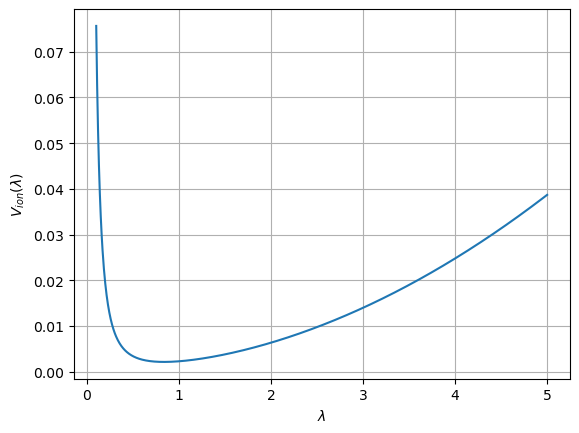

In [8]:
# Minimizamos el potencial en función de lambda
N=100
t, w = gaussxw(N)

a=0
b=1
x = 1/2*((b-a)*t+(b-a))
wx = 1/2*(b-a)*w

a=0
b=2*np.pi
y = 1/2*((b-a)*t+(b-a))
wy = 1/2*(b-a)*w


def F(r, theta, lamb):
    return r*1e-3*(1/lamb**2*np.cos(1/(r**2*np.sin(theta/2)-1))**2+lamb**2*np.sin(2/r**2/np.sin(theta/2)+r*np.sin(theta))**2)

def f(lamb):
    X, Y = np.meshgrid(x, y)
    WX, WY = np.meshgrid(wx, wy)

    I = np.sum(WX*WY*F(X, Y, lamb))
    
    return I
    
f = np.vectorize(f)
lamb = np.linspace(0.1,5,1000)
plt.plot(lamb, f(lamb))
plt.grid()
plt.xlabel("$\\lambda$")
plt.ylabel("$V_{ion}(\\lambda)$")
plt.show()

lambda minimizante: 0.8362175590935076
V_ion(lambda_min)=0.002163299410689733


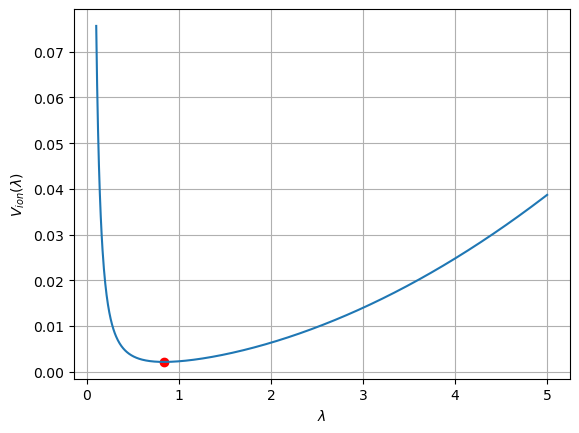

In [9]:
# Procedemos por razón áurea
lambda_min = razon_aurea(f, 0.2,1,1e-9)
Vion = f(lambda_min)

print(f"lambda minimizante: {lambda_min}")
print(f"V_ion(lambda_min)={Vion}")

plt.plot(lambda_min, f(lambda_min), "ro")
plt.plot(lamb, f(lamb))
plt.grid()
plt.xlabel("$\\lambda$")
plt.ylabel("$V_{ion}(\\lambda)$")
plt.show()

$\huge{\text{Parte 2}}$

## Apartado 4

$$V(x)=C_2x^2+C_3x^3+C_4x^4$$

con $x\in(-1,1)$

In [10]:
m=1
g=0

# Construimos trampa de potencial en la sección que se nos indica: y=0, x€ (-1,1)

def V(x):
    return V0*(C2*x**2+C3*x**3+C4*x**4) + Vion



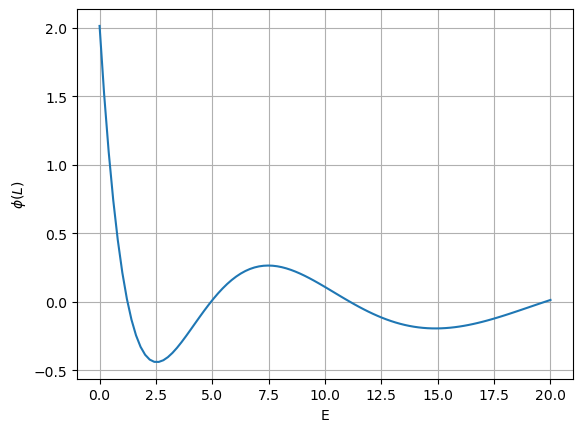

In [18]:
import numpy as np
import matplotlib.pyplot as plt

L = 2
hbar=1

xp = np.linspace(-L/2,L/2,1000)
h = L/1000

def F(r, x, E):
    Psi, der = r
    return np.array([der, ((V(x)-E)*Psi+g*np.abs(Psi)**2)*2*m/hbar**2], float)

def Psi_L(E):
    r = np.array([0,1], float) # Cojo valor arbitrario de der porque no me influye en nada, luego habrá que normalizar Psi resultante
    for x in xp:
        k1 = h*F(r, x, E)
        k2 = h*F(r, x+h/2, E)
        k3 = h*F(r, x+h/2, E)
        k4 = h*F(r, x+h, E)
        
        r += 1/6*(k1+2*k2+2*k3+k4)
        
    return r[0]

# Busco aquel valor de la energía que me permita hacer Psi(L)=0

Psi_L = np.vectorize(Psi_L)

Ep = np.linspace(0,20, 100)

plt.plot(Ep, Psi_L(Ep))
plt.grid()
plt.xlabel("E")
plt.ylabel("$\\phi(1)$")
plt.show()

In [19]:
def biseccion(f, a, b, tol):
    err = 2*tol
    
    while err > tol:
        x_med = (a+b)/2
        if f(a)*f(x_med)>0: # Estoy en el intervalo de a, me he pasado por la izq. --> recorto a=x_med
            a=x_med
        else:
            b=x_med
        err = np.abs(b-a)
        
    return (b+a)/2

E0 = 1.2373948097229004
E1 = 4.9405198097229
E2 = 11.110056936740875


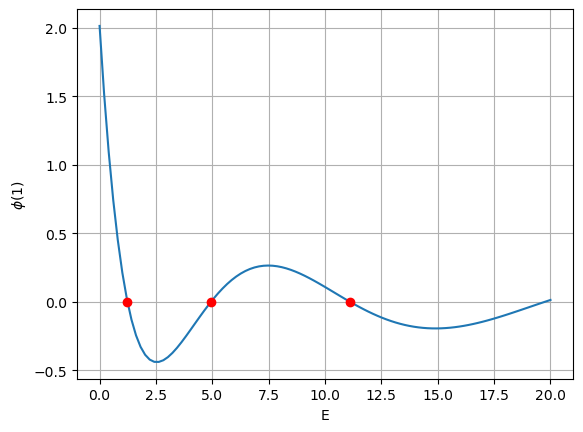

In [21]:
# Buscamos los puntos donde la función se anula. Estas son las energías que permiten resolver el problema con
# unas condiciones de contorno adecuadas y por tanto son las autoenergías del sistema

# Estado fundamental (E0)
a=0.5
b=2.5
E0 = biseccion(Psi_L, a, b, 1e-6)

# Primer excitado (E1)
a=4
b=6
E1 = biseccion(Psi_L, a, b, 1e-6)

# Segundo excitado (E2)
a=10
b=12.5
E2 = biseccion(Psi_L, a, b, 1e-6)

print(f"E0 = {E0}\nE1 = {E1}\nE2 = {E2}")
plt.plot(Ep, Psi_L(Ep))
plt.grid()
plt.xlabel("E")
plt.ylabel("$\\phi(1)$")
plt.plot(E0, Psi_L(E0), "ro")
plt.plot(E1, Psi_L(E1), "ro")
plt.plot(E2, Psi_L(E2), "ro")
plt.show()

In [26]:
# Ahora que conocemos la energía de la función de onda de los estados de interés, resolvemos
# la ec. de Schrodinger (GP cuando g=0) para obtener las funciones de onda correspondientes
# (y, naturalmente, las damos normalizadas)

# Estado fundamental

r = np.array([0,1], float)
Psi0p = []

for x in xp:
    Psi0p.append(r[0])
    k1 = h*F(r, x, E0)
    k2 = h*F(r, x+h/2, E0)
    k3 = h*F(r, x+h/2, E0)
    k4 = h*F(r, x+h, E0)

    r += 1/6*(k1+2*k2+2*k3+k4)

Psi0p = np.array(Psi0p)
# Calculamos integral en (-L/2,L/2)
w = np.ones_like(xp)
w[0]=w[-1]=1/2
C=np.sum(w*np.abs(Psi0p)**2)
Psi0p /= np.sqrt(C)

In [27]:
# Primer excitado

r = np.array([0,1], float)
Psi1p = []

for x in xp:
    Psi1p.append(r[0])
    k1 = h*F(r, x, E1)
    k2 = h*F(r, x+h/2, E1)
    k3 = h*F(r, x+h/2, E1)
    k4 = h*F(r, x+h, E1)

    r += 1/6*(k1+2*k2+2*k3+k4)

Psi1p = np.array(Psi1p)
# Calculamos integral en (-L/2,L/2)
w = np.ones_like(xp)
w[0]=w[-1]=1/2
C=np.sum(w*np.abs(Psi1p)**2)
Psi1p /= np.sqrt(C)

In [28]:
# Segundo excitado

r = np.array([0,1], float)
Psi2p = []

for x in xp:
    Psi2p.append(r[0])
    k1 = h*F(r, x, E2)
    k2 = h*F(r, x+h/2, E2)
    k3 = h*F(r, x+h/2, E2)
    k4 = h*F(r, x+h, E2)

    r += 1/6*(k1+2*k2+2*k3+k4)

Psi2p = np.array(Psi2p)
# Calculamos integral en (-L/2,L/2)
w = np.ones_like(xp)
w[0]=w[-1]=1/2
C=np.sum(w*np.abs(Psi2p)**2)
Psi2p /= np.sqrt(C)

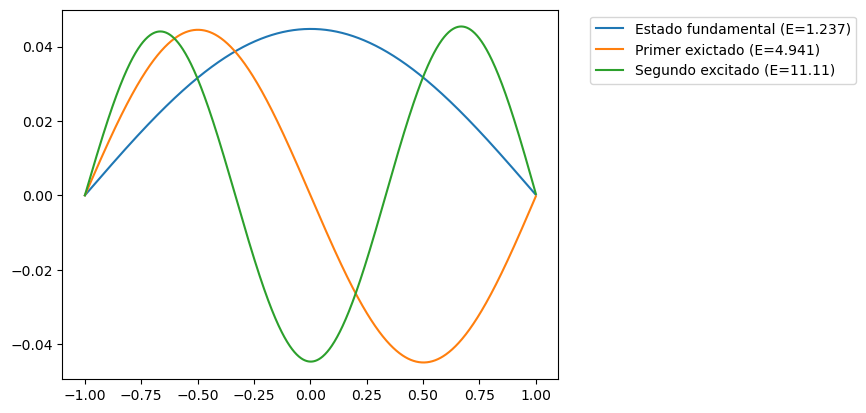

In [35]:
plt.plot(xp, Psi0p, label=f"Estado fundamental (E={np.round(E0, 3)})")
plt.plot(xp, Psi1p, label=f"Primer exictado (E={np.round(E1, 3)})")
plt.plot(xp, Psi2p, label=f"Segundo excitado (E={np.round(E2, 3)})")
#plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.show()

## Apartado 5: repetir todo para límite de interacción débil (g=0.1)

In [45]:
m=1
g=0.1

# Construimos trampa de potencial en la sección que se nos indica: y=0, x€ (-1,1)

def V(x):
    return V0*(C2*x**2+C3*x**3+C4*x**4) + Vion



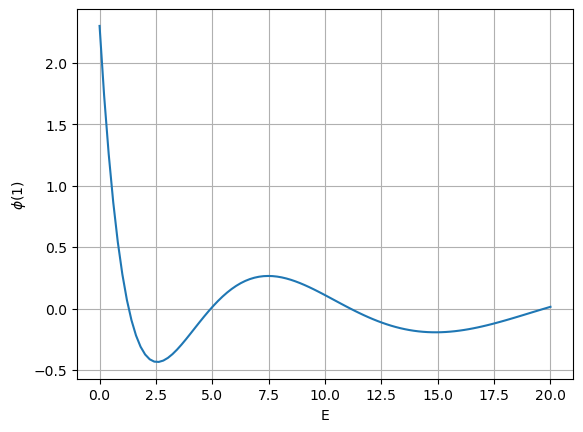

In [46]:
import numpy as np
import matplotlib.pyplot as plt

L = 2
hbar=1

xp = np.linspace(-L/2,L/2,1000)
h = L/1000

def F(r, x, E):
    Psi, der = r
    return np.array([der, ((V(x)-E)*Psi+g*np.abs(Psi)**2)*2*m/hbar**2], float)

def Psi_L(E):
    r = np.array([0,1], float) # Cojo valor arbitrario de der porque no me influye en nada, luego habrá que normalizar Psi resultante
    for x in xp:
        k1 = h*F(r, x, E)
        k2 = h*F(r, x+h/2, E)
        k3 = h*F(r, x+h/2, E)
        k4 = h*F(r, x+h, E)
        
        r += 1/6*(k1+2*k2+2*k3+k4)
        
    return r[0]

# Busco aquel valor de la energía que me permita hacer Psi(L)=0

Psi_L = np.vectorize(Psi_L)

Ep = np.linspace(0,20, 100)

plt.plot(Ep, Psi_L(Ep))
plt.grid()
plt.xlabel("E")
plt.ylabel("$\\phi(1)$")
plt.show()

E0 = 1.2912821769714355
E1 = 4.9405436515808105
E2 = 11.116231381893158


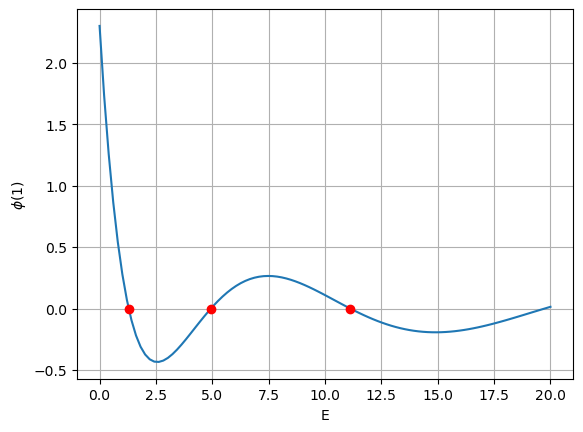

In [47]:
# Buscamos los puntos donde la función se anula. Estas son las energías que permiten resolver el problema con
# unas condiciones de contorno adecuadas y por tanto son las autoenergías del sistema

# Estado fundamental (E0)
a=0.5
b=2.5
E0 = biseccion(Psi_L, a, b, 1e-6)

# Primer excitado (E1)
a=4
b=6
E1 = biseccion(Psi_L, a, b, 1e-6)

# Segundo excitado (E2)
a=10
b=12.5
E2 = biseccion(Psi_L, a, b, 1e-6)

print(f"E0 = {E0}\nE1 = {E1}\nE2 = {E2}")
plt.plot(Ep, Psi_L(Ep))
plt.grid()
plt.xlabel("E")
plt.ylabel("$\\phi(1)$")
plt.plot(E0, Psi_L(E0), "ro")
plt.plot(E1, Psi_L(E1), "ro")
plt.plot(E2, Psi_L(E2), "ro")
plt.show()

In [48]:
# Ahora que conocemos la energía de la función de onda de los estados de interés, resolvemos
# la ec. de Schrodinger (GP cuando g=0) para obtener las funciones de onda correspondientes
# (y, naturalmente, las damos normalizadas)

# Estado fundamental

r = np.array([0,1], float)
Psi0p = []

for x in xp:
    Psi0p.append(r[0])
    k1 = h*F(r, x, E0)
    k2 = h*F(r, x+h/2, E0)
    k3 = h*F(r, x+h/2, E0)
    k4 = h*F(r, x+h, E0)

    r += 1/6*(k1+2*k2+2*k3+k4)

Psi0p = np.array(Psi0p)
# Calculamos integral en (-L/2,L/2)
w = np.ones_like(xp)
w[0]=w[-1]=1/2
C=np.sum(w*np.abs(Psi0p)**2)
Psi0p /= np.sqrt(C)

In [49]:
# Primer excitado

r = np.array([0,1], float)
Psi1p = []

for x in xp:
    Psi1p.append(r[0])
    k1 = h*F(r, x, E1)
    k2 = h*F(r, x+h/2, E1)
    k3 = h*F(r, x+h/2, E1)
    k4 = h*F(r, x+h, E1)

    r += 1/6*(k1+2*k2+2*k3+k4)

Psi1p = np.array(Psi1p)
# Calculamos integral en (-L/2,L/2)
w = np.ones_like(xp)
w[0]=w[-1]=1/2
C=np.sum(w*np.abs(Psi1p)**2)
Psi1p /= np.sqrt(C)

In [50]:
# Segundo excitado

r = np.array([0,1], float)
Psi2p = []

for x in xp:
    Psi2p.append(r[0])
    k1 = h*F(r, x, E2)
    k2 = h*F(r, x+h/2, E2)
    k3 = h*F(r, x+h/2, E2)
    k4 = h*F(r, x+h, E2)

    r += 1/6*(k1+2*k2+2*k3+k4)

Psi2p = np.array(Psi2p)
# Calculamos integral en (-L/2,L/2)
w = np.ones_like(xp)
w[0]=w[-1]=1/2
C=np.sum(w*np.abs(Psi2p)**2)
Psi2p /= np.sqrt(C)

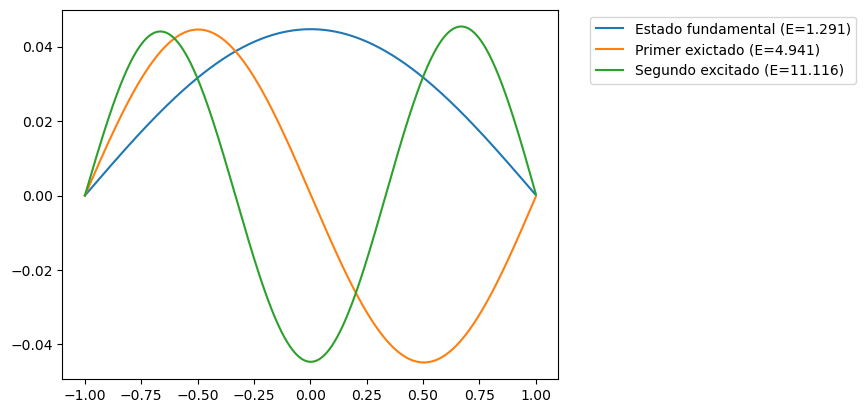

In [51]:
plt.plot(xp, Psi0p, label=f"Estado fundamental (E={np.round(E0, 3)})")
plt.plot(xp, Psi1p, label=f"Primer exictado (E={np.round(E1, 3)})")
plt.plot(xp, Psi2p, label=f"Segundo excitado (E={np.round(E2, 3)})")
#plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.show()

$\huge{\text{Parte 3}}$

# Apartado 7

In [53]:
sigma=0.1
kappa=1

In [66]:
# Resovemos ec. de GP en límite débil cuando por Crank-Nicolson para la partícula
# encerrada en el potencial de caja unidimensional
import numpy as np
import matplotlib.pyplot as plt
from banded import banded

# Parte espacial
L=2
N=1000
xp = np.linspace(-L/2,L/2,N)
a = L/N

# Parte temporal
t0=0
t_max=3
h = 1e-3
tp = np.arange(t0,t_max+h, h)

# Cond. inicial
Psi = np.exp(-xp**2/(2*sigma**2))*np.exp(1j*kappa*xp)
Psi[0]=Psi[-1]=0

Psis_data = []

for t in tp:
    Psis_data.append(np.real(Psi).copy())
    # Matriz A
    a1=1+1j*h/2 * (1/(m*a**2) + V(xp[1:N-1]) +g*np.abs(Psi[1:N-1])**2 )
    a2 = -1j*h/(4*m*a**2)
    
    A = np.empty((3,N-2), complex)
    A[0,:]=a2
    A[1,:]=a1
    A[2,:]=a2
    
    # Matriz B
    b1=1-1j*h/2 * (1/(m*a**2) + V(xp[1:N-1]) +g*np.abs(Psi[1:N-1])**2 )
    b2 = 1j*h/(4*m*a**2)
    b = b1*Psi[1:N-1]+b2*Psi[2:N]+b2*Psi[0:N-2]
    
    Psi[1:N-1]=banded(A, b, 1, 1)

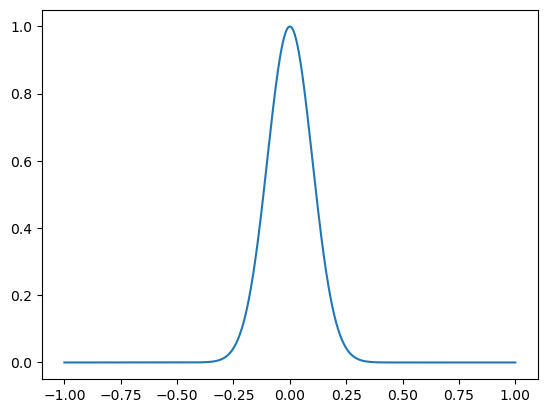

In [67]:
from matplotlib.animation import FuncAnimation
from IPython.core.display import HTML

fig, ax = plt.subplots()

def animacion(frames):
    ax.clear()
    ax.plot(xp, Psis_data[frames])
    

anim=FuncAnimation(fig,animacion,frames=200,interval=20)
HTML(anim.to_jshtml())